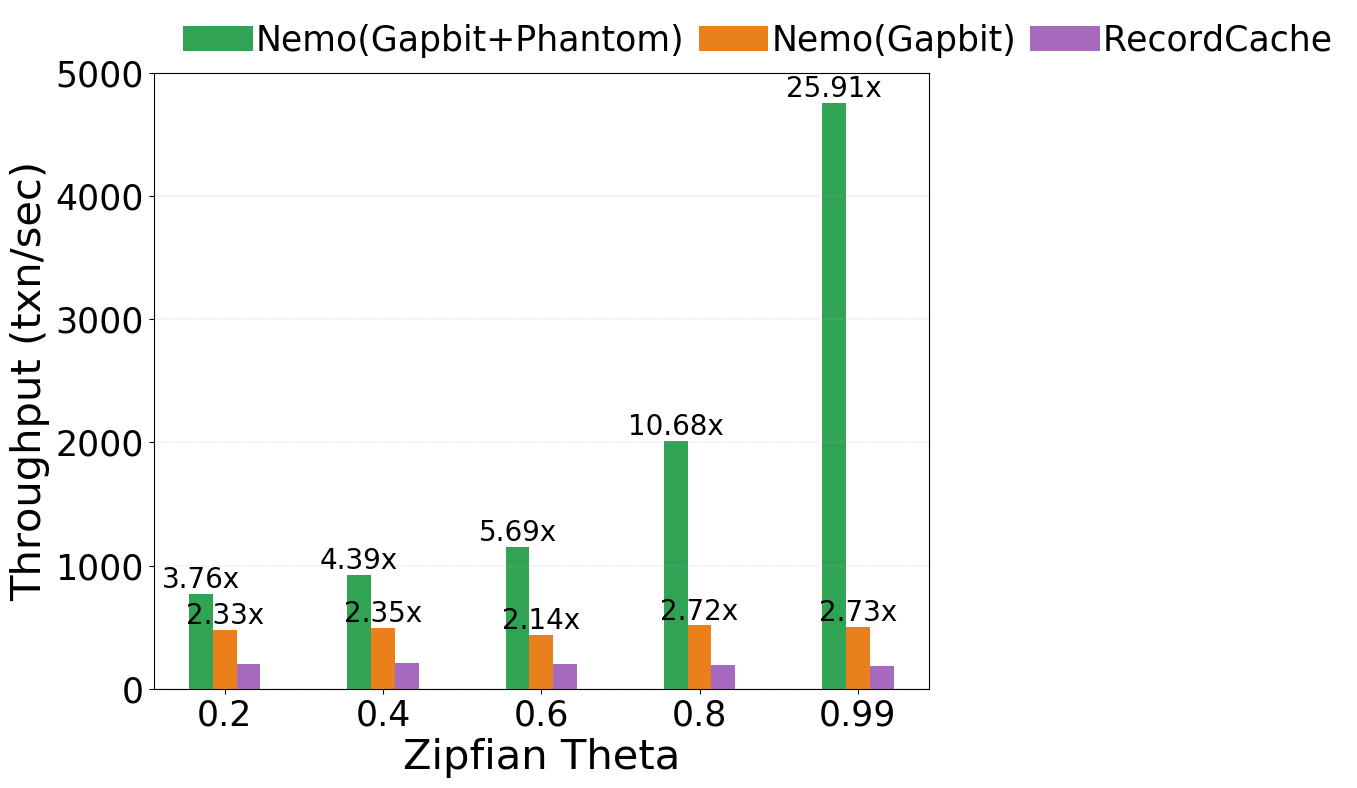

In [10]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
x_dimension = "zipf_theta_"
color_indices, line_colors = select_color_idx(4)
# nemo_batch_evict_c = "#31a354"
# nemo_record_evict_c =  "#ea801c"

nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
nemo_record_cache_c = line_colors["PURPLE"]
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "Nemo(Gapbit+Phantom)"
nemo_record_evict_label = "Nemo(Gapbit)"
nemo_record_cache_label = "RecordCache"

datadir = "../../output/"
exp_tuple_batch_evict = "exp_negative_range_100m_skew-recordsz1024-buf0.25-read1-negative0"
exp_tuple_record_evict = "exp_negative_range_100m_skew-recordsz1024-buf0.25-read1-negative1"
exp_record_cache = "exp_negative_range_100m_skew-recordsz1024-buf0.25-read1-negative2"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)


# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)

data_record_cache = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_record_cache + ".txt")]
df_record_cache = pd.DataFrame().from_records(data_record_cache).sort_values(by=x_dimension)


fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(data_tuple_batch))
offset = bar_width

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset , df_tuple_batch["throughput_txn_per_sec"], bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices, df_tuple_record["throughput_txn_per_sec"], bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)
record_cache_bars = ax1.bar(indices + offset, df_record_cache["throughput_txn_per_sec"], bar_width, label=nemo_record_cache_label, color=nemo_record_cache_c)

speedup = ((df_tuple_batch["throughput_txn_per_sec"] / 
           df_record_cache["throughput_txn_per_sec"] ) )


for idx, (bar, gain) in enumerate(zip(batch_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)

speedup = ((df_tuple_record["throughput_txn_per_sec"] / 
           df_record_cache["throughput_txn_per_sec"] ) )


for idx, (bar, gain) in enumerate(zip(record_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)


ax1.set_xticks(indices)
ax1.set_xticklabels(df_tuple_batch[x_dimension], fontsize=ticksize)

# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylim(50, 200000)
ax1.set_ylim(0, 5000)

ax1.set_ylabel("Throughput (txn/sec)", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
ax1.set_xlabel("Zipfian Theta", fontsize=txtsize)
# ax1.set_xlabel("Record Size (100K rows, cache size = data size, Read-only, Uniform Dist)", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax1.title.set_text("Throughput Comparison")
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




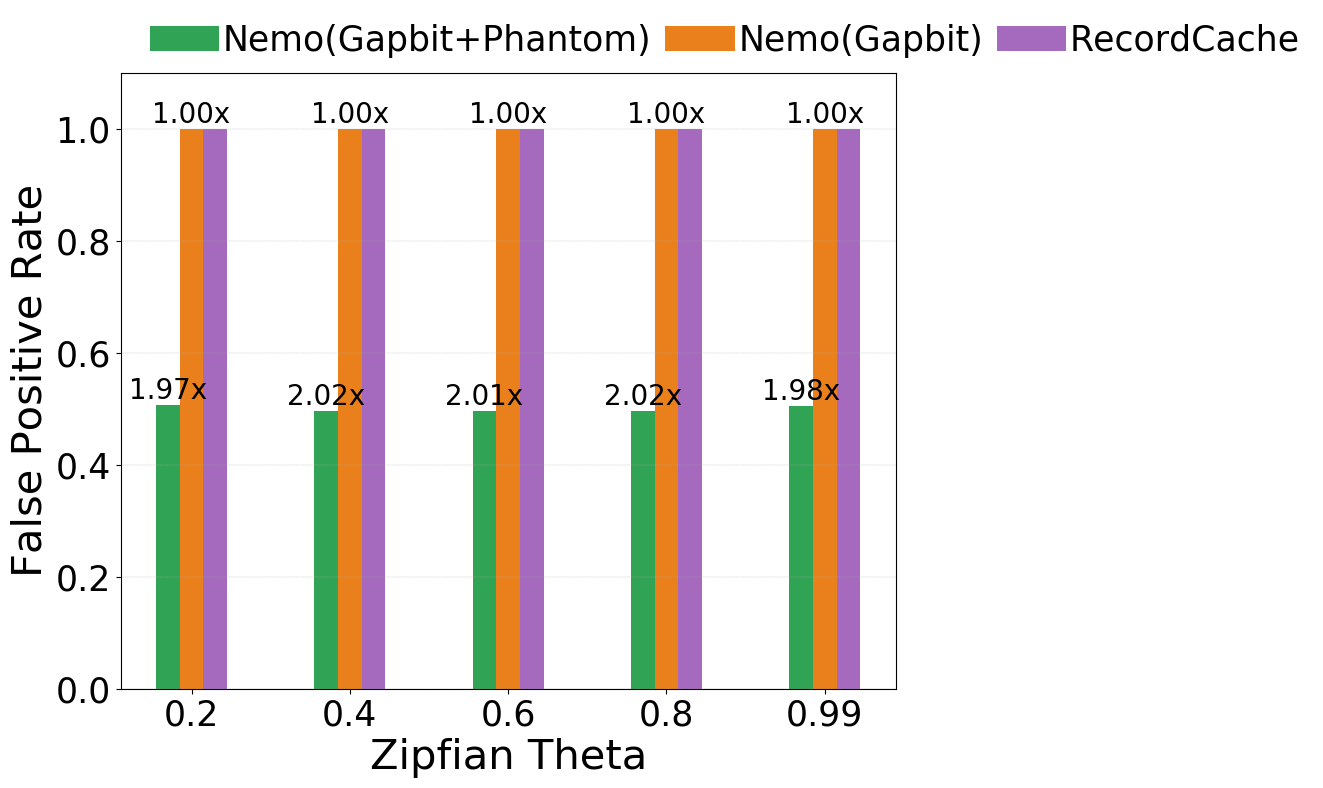

In [8]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
x_dimension = "zipf_theta_"

nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
nemo_record_cache_c = line_colors["PURPLE"]
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "Nemo(Gapbit+Phantom)"
nemo_record_evict_label = "Nemo(Gapbit)"
nemo_record_cache_label = "RecordCache"

datadir = "../../output/"
exp_tuple_batch_evict = "exp_negative_range_100m_skew-recordsz1024-buf0.25-read1-negative0"
exp_tuple_record_evict = "exp_negative_range_100m_skew-recordsz1024-buf0.25-read1-negative1"
exp_record_cache = "exp_negative_range_100m_skew-recordsz1024-buf0.25-read1-negative2"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)


# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)

data_record_cache = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_record_cache + ".txt")]
df_record_cache = pd.DataFrame().from_records(data_record_cache).sort_values(by=x_dimension)

batch_false_positive_rate = df_tuple_batch["false_positive_"]/(df_tuple_batch["false_positive_"] + df_tuple_batch["true_negative_"]) 
record_false_positive_rate = df_tuple_record["false_positive_"]/(df_tuple_record["false_positive_"] + df_tuple_record["true_negative_"])
record_cache_false_positive_rate = df_record_cache["false_positive_"]/(df_record_cache["false_positive_"] + df_record_cache["true_negative_"])
fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(data_tuple_batch))
offset = bar_width

# Bar chart for the primary data
# print(df_tuple_batch["tuple_hit_rate_"])
# print(1- df_tuple_batch["tuple_hit_rate_"])
batch_bars = ax1.bar(indices - offset , batch_false_positive_rate, bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices , record_false_positive_rate, bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)
record_cache_bars = ax1.bar(indices + offset, record_cache_false_positive_rate, bar_width, label=nemo_record_cache_label, color=nemo_record_cache_c)

speedup = (record_cache_false_positive_rate / 
           batch_false_positive_rate )


for idx, (bar, gain) in enumerate(zip(batch_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)


speedup = (record_cache_false_positive_rate / 
           record_false_positive_rate )


for idx, (bar, gain) in enumerate(zip(record_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)

ax1.set_xticks(indices)
ax1.set_xticklabels(df_tuple_batch[x_dimension], fontsize=ticksize)
# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylim(50, 200000)
ax1.set_ylim(0, 1.1)

ax1.set_ylabel("False Positive Rate", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
# ax1.set_xlabel("Record Size", fontsize=ticksize)
ax1.set_xlabel("Zipfian Theta", fontsize=txtsize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)

legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




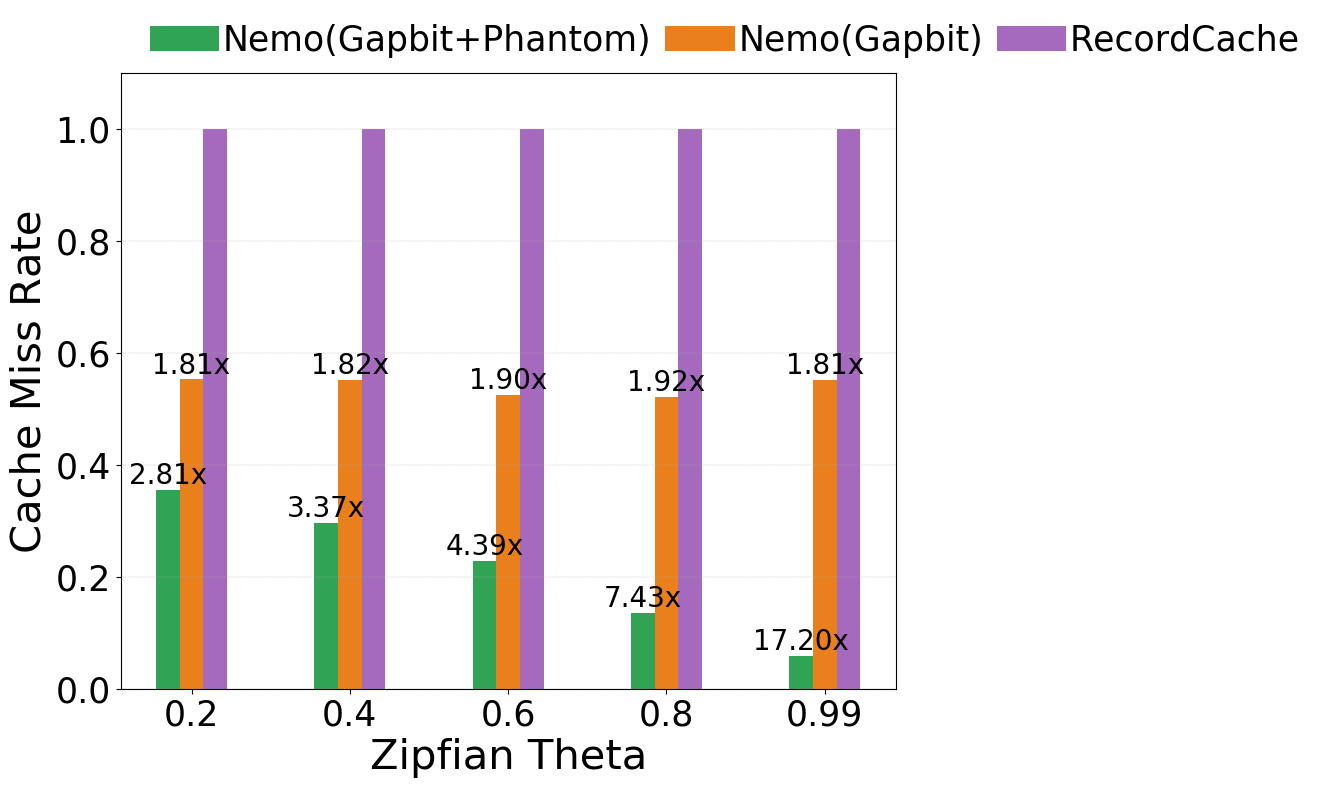

In [9]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25

x_dimension = "zipf_theta_"

nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
nemo_record_cache_c = line_colors["PURPLE"]
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "Nemo(Gapbit+Phantom)"
nemo_record_evict_label = "Nemo(Gapbit)"
nemo_record_cache_label = "RecordCache"

datadir = "../../output/"
exp_tuple_batch_evict = "exp_negative_range_100m_skew-recordsz1024-buf0.25-read1-negative0"
exp_tuple_record_evict = "exp_negative_range_100m_skew-recordsz1024-buf0.25-read1-negative1"
exp_record_cache = "exp_negative_range_100m_skew-recordsz1024-buf0.25-read1-negative2"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)


# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)

data_record_cache = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_record_cache + ".txt")]
df_record_cache = pd.DataFrame().from_records(data_record_cache).sort_values(by=x_dimension)






fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(data_tuple_batch))
offset = bar_width

# Bar chart for the primary data
# print(df_tuple_batch["tuple_hit_rate_"])
# print(1- df_tuple_batch["tuple_hit_rate_"])
batch_bars = ax1.bar(indices - offset , 1- df_tuple_batch["tuple_hit_rate_"], bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices , 1- df_tuple_record["tuple_hit_rate_"], bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)
record_cache_bars = ax1.bar(indices + offset, 1- df_record_cache["tuple_hit_rate_"], bar_width, label=nemo_record_cache_label, color=nemo_record_cache_c)

speedup = (((1-df_record_cache["tuple_hit_rate_"]) / 
           (1-df_tuple_batch["tuple_hit_rate_"]) ) )


for idx, (bar, gain) in enumerate(zip(batch_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)


speedup = (((1-df_record_cache["tuple_hit_rate_"]) / 
           (1-df_tuple_record["tuple_hit_rate_"]) ) )


for idx, (bar, gain) in enumerate(zip(record_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)


ax1.set_xticks(indices)
ax1.set_xticklabels(df_tuple_batch[x_dimension], fontsize=ticksize)
# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylim(50, 200000)
ax1.set_ylim(0, 1.1)

ax1.set_ylabel("Cache Miss Rate", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
# ax1.set_xlabel("Record Size", fontsize=ticksize)
ax1.set_xlabel("Zipfian Theta", fontsize=txtsize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)

legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')


